In [1]:
import pickle
with open("smart_building_data_2021.pkl", "rb") as f:
    input_data = pickle.load(f)

# "calorimeter_df": calorimeter_df,
# "zone_air_temperature_df": zone_air_temperature_df,
# "zone_fan_speed_df": zone_fan_speed_df,
# "fcu_return_medium_temperature_df": fcu_return_medium_temperature_df,



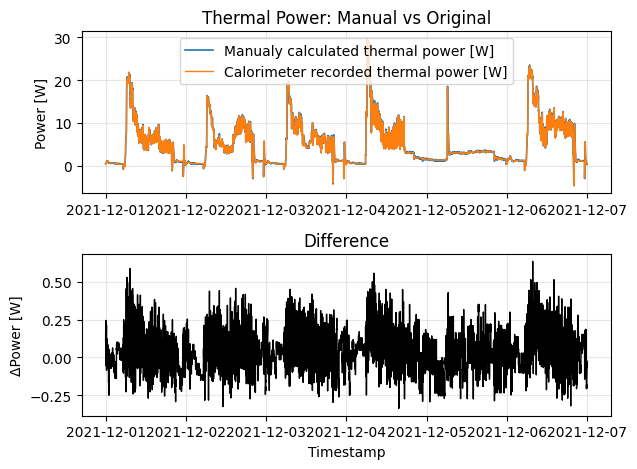

,supply_temperature,return_temperature,mass_volume_flow,thermal_power,missing_data_flag,mass_flow_kgs,dT,thermal_power_man
timestamp,,,,,,,,
2021-12-01 00:00:00,39.5,36.3,110.0,0.3,0,0.030556,3.2,0.409298
2021-12-01 00:01:00,39.5,36.1,120.0,0.3,0,0.033333,3.4,0.474413


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Specific heat capacity of water [J/(kg*K)]
c_w = 4186
# Density of water [kg/m3] - approx. (can vary slightly with temperature)
rho = 1000

cal_df = input_data['calorimeter_df'].copy()
# Ensure timestamp is datetime and set as index
cal_df['timestamp'] = pd.to_datetime(cal_df['timestamp'])
cal_df = cal_df.set_index('timestamp').sort_index()
# Convert mass flow from kg/h → kg/s
cal_df["mass_flow_kgs"] = cal_df["mass_volume_flow"] / 3600
# Temperature difference
cal_df["dT"] = cal_df["supply_temperature"] - cal_df["return_temperature"]
# Manual thermal power [kW]
cal_df["thermal_power_man"] = 1e-3 * c_w * cal_df["mass_flow_kgs"] * cal_df["dT"]

# Plot comparison head
start_date=pd.Timestamp("2021-12-01")
end_date=pd.Timestamp("2021-12-07")
print_df = cal_df.loc[start_date : end_date].copy()
if print_df.empty:
    print("No data in this time interval.")


 # Manual vs original
plt.subplot(2, 1, 1)
plt.plot(print_df.index, print_df["thermal_power_man"], label="Manualy calculated thermal power [W]", linewidth=1.2)
plt.plot(print_df.index, print_df["thermal_power"], label="Calorimeter recorded thermal power [W]", linewidth=1.0)
plt.title("Thermal Power: Manual vs Original")
plt.ylabel("Power [W]")
plt.grid(alpha=0.3)
plt.legend()

# Difference
plt.subplot(2, 1, 2)
plt.plot(print_df.index, print_df["thermal_power_man"] - print_df["thermal_power"],
         label="Difference (manual - original)", color="black", linewidth=1)
plt.title("Difference")
plt.xlabel("Timestamp")
plt.ylabel("ΔPower [W]")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print_df.head(2)


In [3]:
import pandas as pd

# --- 1) Detect timestamps where any zone changes its fan speed ---
# A change occurs when any column differs from its previous row
change_mask = input_data['zone_fan_speed_df'].ne(input_data['zone_fan_speed_df'].shift()).any(axis=1)
change_times = input_data['zone_fan_speed_df'].index[change_mask]
# Convert change_times (DatetimeIndex) into a DataFrame for grouping
changes_df = pd.DataFrame({"timestamp": change_times})
changes_df["date"] = changes_df["timestamp"].dt.date
# --- Count how many changes happen per day ---
daily_counts = changes_df.groupby("date").size()
# daily_counts = total number of changes per day (all zones combined)
n_zones = len(input_data['zone_fan_speed_df'].columns)
daily_avg_per_zone = daily_counts / n_zones
print("\n=== Summary ===")
print(f"Number of zones: {n_zones}")
print(f"Overall average changes per zone per day: {daily_avg_per_zone.mean():.2f}")
print(f"Min per-zone daily average: {daily_avg_per_zone.min():.2f}")
print(f"Max per-zone daily average: {daily_avg_per_zone.max():.2f}")



=== Summary ===
Number of zones: 7
Overall average changes per zone per day: 88.41
Min per-zone daily average: 0.14
Max per-zone daily average: 205.71


In [4]:
# --- 2) Build timestamps to remove: change moments + 15 minutes after each change ---
fan_df = input_data['zone_fan_speed_df']
zone_df = input_data['zone_air_temperature_df']

print(f"Shape: {fan_df.shape}")
print(f"Shape: {zone_df.shape}")

# --- Base mask: change moment + 15-minute window ---
mask_window = pd.Series(False, index=fan_df.index)
for t in change_times:
    mask_window |= (fan_df.index >= t) & (fan_df.index <= t + pd.Timedelta(minutes=15))
# --- Additional rule 1: remove timestamps where ANY fan zone is NaN ---
fan_nan_mask = fan_df.isna().any(axis=1)
# --- Additional rule 2: remove timestamps where ANY zone temperature is NaN ---
zone_nan_mask = zone_df.isna().any(axis=1)
# --- Additional rule 3: remove timestamps where ANY calorimeter value is NaN ---
cal_nan_mask = cal_df.isna().any(axis=1)
# --- Additional rule 4:  Mass-flow jumps: Δm ≥ 500/3600 kg/s
mass_flow = cal_df["mass_volume_flow"]
flow_diff = mass_flow.diff().abs()
flow_jump_threshold = 100.0 # prag skoka (360/3600 kg/s ≈ 0.1)
flow_jump_mask  = flow_diff >= flow_jump_threshold
flow_jump_times = mass_flow.index[flow_jump_mask]
flow_jump_mask = pd.Series(False, index=fan_df.index)
for t in flow_jump_times:
    flow_jump_mask |= (
        (fan_df.index >= t - pd.Timedelta(minutes=5)) &
        (fan_df.index <= t + pd.Timedelta(minutes=30))
    )
# --- Additional rule 5: T_supply jumps > 5°C, ukloni 30 min poslije skoka ---
Ts = cal_df["supply_temperature"]
Ts_diff = Ts.diff().abs()
Ts_jump_mask = Ts_diff > 4.0
Ts_jump_times = Ts.index[Ts_jump_mask]
Ts_jump_window_mask = pd.Series(False, index=cal_df.index )
for t in Ts_jump_times:
    Ts_jump_window_mask |= ((cal_df.index >= t - pd.Timedelta(minutes=5)) &
                            (cal_df.index <= t + pd.Timedelta(minutes=30)))
# --- Combine all removal masks ---
final_mask = mask_window | fan_nan_mask | zone_nan_mask | cal_nan_mask | flow_jump_mask | Ts_jump_window_mask
times_to_remove = fan_df.index[final_mask]

# --- Diagnostics ---
print("\n=== Removal Window ===")
print(f"Timestamps in change + 15-min windows: {mask_window.sum()}")
print(f"Timestamps with ANY NaN in fan_df:        {fan_nan_mask.sum()}")
print(f"Timestamps with ANY NaN in zone_df:       {zone_nan_mask.sum()}")
print(f"Timestamps with ANY NaN in cal_df:        {cal_nan_mask.sum()}")
print(f"Timestamps in ±15 min around mass-flow jumps: {flow_jump_mask.sum()}")
print(f"Timestamps in ±15 min around supply temperature jumps: {flow_jump_mask.sum()}")
print(f"TOTAL timestamps to remove:               {len(times_to_remove)}")

Shape: (448577, 7)
Shape: (448577, 7)

=== Removal Window ===
Timestamps in change + 15-min windows: 204002
Timestamps with ANY NaN in fan_df:        122279
Timestamps with ANY NaN in zone_df:       122279
Timestamps with ANY NaN in cal_df:        5724
Timestamps in ±15 min around mass-flow jumps: 45221
Timestamps in ±15 min around supply temperature jumps: 45221
TOTAL timestamps to remove:               221643


In [5]:
# --- 3) Remove timestamps from fan_df, zone_df, cal_df ---

# Cleaned versions
fan_df_clean  = fan_df.loc[~fan_df.index.isin(times_to_remove)].copy()
zone_df_clean = zone_df.loc[~zone_df.index.isin(times_to_remove)].copy()
cal_df_clean  = cal_df.loc[~cal_df.index.isin(times_to_remove)].copy()


# Save to CSV files
fan_df_clean.to_csv('fan_data_cleaned.csv')
zone_df_clean.to_csv('zone_data_cleaned.csv')
cal_df_clean.to_csv('cal_data_cleaned.csv')

# They all share the same final size now
remaining = fan_df_clean.shape[0]
print(f"\nNumber of samples left after cleaning: {remaining}")




Number of samples left after cleaning: 226934


In [1]:
import pandas as pd
cal_df_clean = pd.read_csv('cal_data_cleaned.csv')
zone_df_clean = pd.read_csv('zone_data_cleaned.csv')
fan_df_clean = pd.read_csv('fan_data_cleaned.csv')

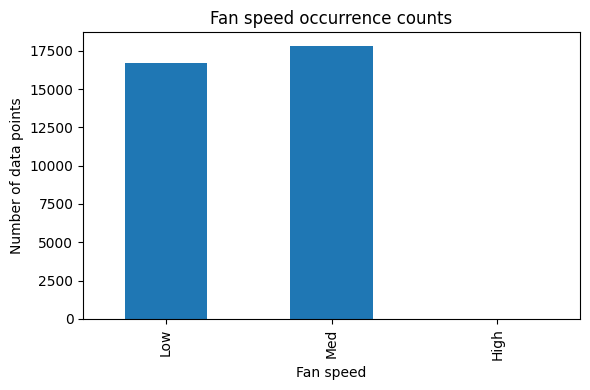


=== Fan speed counts ===
Low     16706
Med     17812
High        0
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt

# Flatten all fan-zone speeds into one series
fan_values = fan_df_clean.values.flatten()

# Remove NaN (should not exist after cleaning, but just in case)
fan_values = pd.Series(fan_values).dropna()

# Map numeric values to labels for the x-axis
speed_labels = {0.5: "Low", 1.0: "Med", 1.5: "High"}

counts = fan_values.map(speed_labels).value_counts().reindex(["Low","Med","High"], fill_value=0)

# Plot
plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Fan speed occurrence counts")
plt.xlabel("Fan speed")
plt.ylabel("Number of data points")
plt.tight_layout()
plt.show()

print("\n=== Fan speed counts ===")
print(counts)


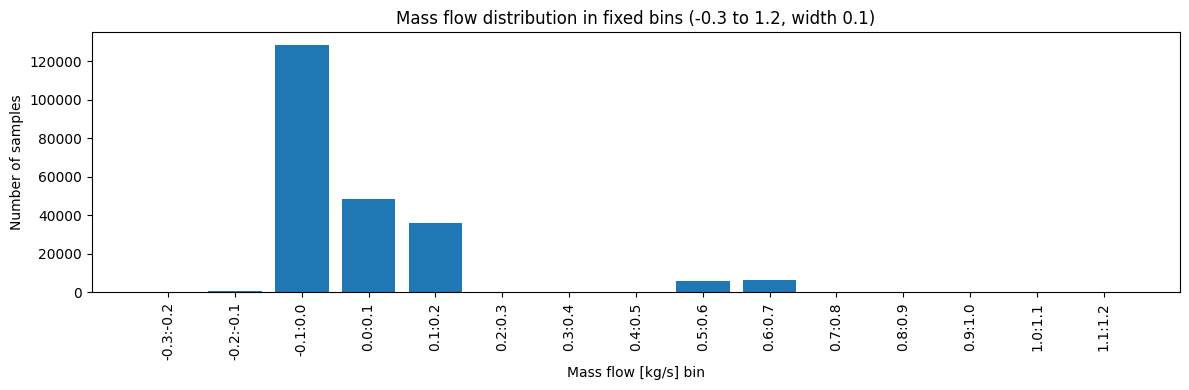


=== Summary ===
Total samples (clean):         226934
Samples within [-0.3, 1.2]:    226934
Samples treated as outliers:   0


In [3]:
import numpy as np
# --- Mass flow distribution in fixed bins, outliers removed ---
# Adjust column name if different
mass_flow = cal_df_clean["mass_flow_kgs"].copy()

# Keep only values within [-0.3, 1.2]
valid_mask = (mass_flow >= -0.3) & (mass_flow <= 1.2)
mass_flow_valid = mass_flow[valid_mask]

# Define bin edges: -0.3, -0.2, -0.1, ..., 1.2
bins = np.arange(-0.3, 1.2 + 0.1, 0.1)

# Compute histogram counts
counts, edges = np.histogram(mass_flow_valid, bins=bins)

# Make nicer text labels for each bin
bin_labels = [f"{edges[i]:.1f}:{edges[i+1]:.1f}" for i in range(len(edges)-1)]

# Plot distribution
plt.figure(figsize=(12, 4))
plt.bar(bin_labels, counts)
plt.xticks(rotation=90)
plt.xlabel("Mass flow [kg/s] bin")
plt.ylabel("Number of samples")
plt.title("Mass flow distribution in fixed bins (-0.3 to 1.2, width 0.1)")
plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print(f"Total samples (clean):         {len(mass_flow)}")
print(f"Samples within [-0.3, 1.2]:    {len(mass_flow_valid)}")
print(f"Samples treated as outliers:   {len(mass_flow) - len(mass_flow_valid)}")

=== Cluster counts ===
mass_flow_kgs
off        128820
cooling     84675
heating     12870
other         569
Name: count, dtype: int64


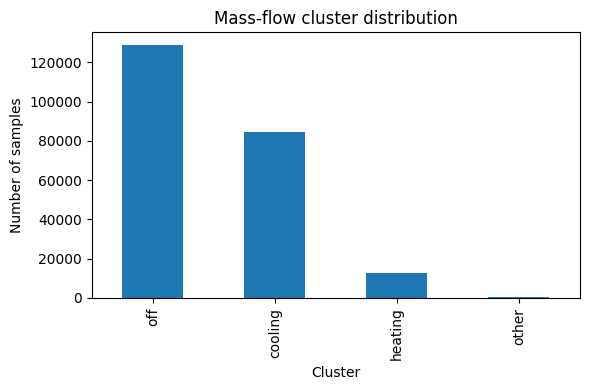

In [4]:
def classify_flow(x):
    # OFF cluster
    if -0.1 <= x <= 0:
        return "off"
    # Cooling cluster
    if 0 <= x <= 0.2:
        return "cooling"
    # Heating cluster
    if 0.5 <= x <= 0.8:
        return "heating"
    # Everything else
    return "other"

flow_cluster = mass_flow.apply(classify_flow)
cluster_counts = flow_cluster.value_counts()
print("=== Cluster counts ===")
print(cluster_counts)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
cluster_counts.plot(kind="bar")
plt.title("Mass-flow cluster distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

In [5]:
pip install cvxopt

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: cvxopt in c:\users\martin\appdata\local\programs\python\python311\lib\site-packages (1.3.2)




[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
from cvxopt import matrix, solvers  # <-- make sure cvxopt is installed

# Ensure same index and sorted
cal_df_clean = cal_df_clean.sort_index()
zone_df_clean = zone_df_clean.sort_index()
fan_df_clean = fan_df_clean.sort_index()

common_index = cal_df_clean.index.intersection(zone_df_clean.index).intersection(fan_df_clean.index)
cal_df_clean = cal_df_clean.loc[common_index]
zone_df_clean = zone_df_clean.loc[common_index]
fan_df_clean = fan_df_clean.loc[common_index]


# --- 1) Flow clusters (based on mass_flow_kgs) ---
def classify_flow(x):
    """Return flow cluster label based on mass flow in kg/s."""
    if pd.isna(x):
        return "Other"
    if -0.1 <= x <= 0.1:
        return "Off"
    if 0 <= x <= 0.4:
        return "Cooling"
    if 0.5 <= x <= 1.2:
        return "Heating"
    return "Other"   # everything else we ignore in LLS

cal_df_clean["flow_cluster"] = cal_df_clean["mass_flow_kgs"].apply(classify_flow)

# --- 2) Fan-state clusters (based on numeric fan speed) ---
def classify_fan_speed(v):
    """Map numerical fan speed to discrete states."""
    # First check if v is None or NaN
    if pd.isna(v):
        return None
    
    # Try to convert to float if it's a string
    try:
        v_float = float(v)
    except (ValueError, TypeError):
        return None
    
    # Now use the float value for comparison
    # use rounding tolerance to be robust
    if np.isclose(v_float, 0.0):
        return "Off"
    if np.isclose(v_float, 0.5):
        return "Low"
    if np.isclose(v_float, 1.0):
        return "Medium"
    if np.isclose(v_float, 1.5):
        return "High"
    return None  # unknown / ignore

# Predefine valid states and combination indexing
flow_states = ["Off", "Cooling", "Heating"]
fan_states  = ["Off", "Low", "Medium", "High"]

# Map (flow_state, fan_state) -> 0..11
comb_pairs = [(fs, fsn) for fs in flow_states for fsn in fan_states]
comb_index = {pair: i for i, pair in enumerate(comb_pairs)}

zone_cols = list(zone_df_clean.columns)
n_zones = len(zone_cols)
n_combos = len(comb_pairs)     # 12
n_params = n_zones * n_combos  # 13 * 12 = 156

print(f"Number of zones: {n_zones}")
print(f"Number of parameters: {n_params} (= {n_zones} zones × {n_combos} (flow, fan) combos)")

# --- 3) Build design matrix X and target vector y ---
rows = []
y_vals = []

for t in cal_df_clean.index:
    flow_state = cal_df_clean.at[t, "flow_cluster"]
    # Skip timestamps not in one of the 3 main flow clusters
    if flow_state not in flow_states:
        continue

    supply_T = cal_df_clean.at[t, "supply_temperature"]

    # One row in X (1 x (n_zones * n_combos))
    row = np.zeros(n_params, dtype=float)
    row_used = False

    for z_idx, zone_name in enumerate(zone_cols):
        # Zone air temperature
        z_temp = zone_df_clean.at[t, zone_name]

        # Fan speed state for this zone
        fan_val = fan_df_clean.at[t, zone_name]
        fan_state = classify_fan_speed(fan_val)

        # If this fan state is not one of Off/Low/Medium/High, skip this zone in this sample
        if fan_state not in fan_states or pd.isna(z_temp) or pd.isna(supply_T):
            continue

        # Determine combination index (flow_state, fan_state)
        comb_id = comb_index[(flow_state, fan_state)]

        # Position in row for this zone and this combination
        param_pos = z_idx * n_combos + comb_id

        # ΔT = supply - zone
        delta_T = supply_T - z_temp

        row[param_pos] = delta_T
        row_used = True

    # If at least one zone contributed, keep this sample
    if row_used:
        rows.append(row)
        y_vals.append(cal_df_clean.at[t, "thermal_power_man"])
        if cal_df_clean.at[t, "thermal_power_man"] > 20:
            print(t)
            print(cal_df_clean.at[t, "thermal_power_man"])
# Final design matrix and target vector
X = np.vstack(rows)
y = np.array(y_vals)

print("\n=== LLS matrix shapes ===")
print(f"X shape: {X.shape}  (samples × parameters)")
print(f"y shape: {y.shape}")

# --- 4a) Solve ordinary least squares ---
theta_ols, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print("\n=== Ordinary LLS solution ===")
print(f"Number of parameters: {len(theta_ols)}")
print(f"Rank of X: {rank}")
print(f"Residual sum of squares: {residuals}")

# --- 4b) Solve constrained least squares with theta >= 0 using CVXOPT QP ---

# We solve:   min 0.5 * ||X θ - y||^2   s.t.  θ >= 0
# This is equivalent to QP:
#   min 0.5 θ^T P θ + q^T θ
#   s.t. G θ <= h
#
# with:
#   P = 2 X^T X
#   q = -2 X^T y
#   G = -I,  h = 0   (because -θ <= 0  <=>  θ >= 0)

XtX = X.T @ X
Xty = X.T @ y

# Small Tikhonov regularization to avoid numerical issues (optional but helpful)
lambda_reg = 1e-6
P_np = 2.0 * (XtX + lambda_reg * np.eye(n_params))
q_np = -2.0 * Xty

# ----- bounds -----
lower_bound = 0.0   # you can change this
upper_bound = 3.0   # and this

# Inequality constraints θ >= 0  ->  -I θ <= 0
G_lower = -np.eye(n_params)
h_lower = -lower_bound * np.ones(n_params)

G_upper = np.eye(n_params)
h_upper = upper_bound * np.ones(n_params)

G_np = np.vstack([G_lower, G_upper])
h_np = np.hstack([h_lower, h_upper])

# Convert to cvxopt matrices
P = matrix(P_np)
q = matrix(q_np)
G = matrix(G_np)
h = matrix(h_np)

# Turn off verbose solver output if you want
solvers.options["show_progress"] = False

solution = solvers.qp(P, q, G, h)
theta_constrained = np.array(solution["x"]).reshape(-1)

print("\n=== Constrained LLS solution (θ >= 0) ===")
print(f"Number of parameters: {len(theta_constrained)}")
print(f"Solver status: {solution['status']}")

# --- 5) Reshape parameters into tables for easier inspection ---
# For ordinary least squares
theta_matrix_ols = theta_ols.reshape(n_zones, n_combos)
param_df_ols = pd.DataFrame(
    theta_matrix_ols,
    index=zone_cols,
    columns=[f"{fs}_{fsn}" for (fs, fsn) in comb_pairs],
)

# For constrained least squares
theta_matrix_constrained = theta_constrained.reshape(n_zones, n_combos)
param_df_constrained = pd.DataFrame(
    theta_matrix_constrained,
    index=zone_cols,
    columns=[f"{fs}_{fsn}" for (fs, fsn) in comb_pairs],
)

# Print some comparison info
print("\n=== Comparison ===")
print(f"Ordinary LLS - Min parameter: {theta_ols.min():.4f}, Max parameter: {theta_ols.max():.4f}")
print(f"Constrained LLS - Min parameter: {theta_constrained.min():.4f}, Max parameter: {theta_constrained.max():.4f}")
print(f"Number of negative parameters in OLS: {(theta_ols < 0).sum()}")

Number of zones: 8
Number of parameters: 96 (= 8 zones × 12 (flow, fan) combos)
28903
26.67412222222222
28904
26.68575000000001

=== LLS matrix shapes ===
X shape: (226393, 96)  (samples × parameters)
y shape: (226393,)

=== Ordinary LLS solution ===
Number of parameters: 96
Rank of X: 56
Residual sum of squares: []

=== Constrained LLS solution (θ >= 0) ===
Number of parameters: 96
Solver status: optimal

=== Comparison ===
Ordinary LLS - Min parameter: -0.1656, Max parameter: 0.4712
Constrained LLS - Min parameter: 0.0000, Max parameter: 1.4991
Number of negative parameters in OLS: 38


In [7]:


# --- 6) Save parameters to disk as pickle ---
param_df_constrained.to_pickle("fcu_parameters_data_from_2018.pkl")
print("\nSaved constrained parameters to 'fcu_parameters_data_from_2018.pkl'")
print("\nSample of parameter dataframe:")
print(param_df_constrained)

import numpy as np
import pandas as pd

# -------------- konfiguracija --------------
flow_states = ["Off", "Cooling", "Heating"]
fan_states  = ["Off", "Low", "Medium", "High"]
MIN_SAMPLES = 10

fan_state_map = {
    0.0: "Off",
    0.5: "Low",
    1.0: "Medium",
    1.5: "High",
}

zone_ids = list(zone_df_clean.columns)

# DataFrame koji će imati ISTU strukturu kao param_df,
# ali će sadržavati broj uzoraka po (zona, flow, fan)
sample_counts = pd.DataFrame(
    0,
    index=zone_ids,
    columns=[f"{fs}_{fsn}" for fs in flow_states for fsn in fan_states],
    dtype=int,
)

# -------------- brojanje uzoraka po zoni i kombinaciji --------------
for zone_id in zone_ids:
    fan_series = fan_df_clean[zone_id]
    fan_labels = fan_series.map(fan_state_map)

    combo_df = pd.DataFrame({
        "flow_cluster": cal_df_clean["flow_cluster"],
        "fan_state": fan_labels,
    }).dropna()

    combo_df = combo_df[
        combo_df["flow_cluster"].isin(flow_states) &
        combo_df["fan_state"].isin(fan_states)
    ]

    combo_counts = (
        combo_df
        .value_counts(["flow_cluster", "fan_state"])
        .rename("n_samples")
        .reset_index()
    )

    for _, row in combo_counts.iterrows():
        flow = row["flow_cluster"]
        fan  = row["fan_state"]
        n    = int(row["n_samples"])
        col_name = f"{flow}_{fan}"
        if col_name in sample_counts.columns:
            sample_counts.at[zone_id, col_name] = n

print("\n=== Sample counts table shape ===")
print(sample_counts.shape)

# -------------- postavi parametre s malo podataka na NaN --------------
mask_few = sample_counts < MIN_SAMPLES
param_df_masked = param_df_constrained.mask(mask_few)

# ako želiš, overwrite originalnog:
param_df_constrained[:] = param_df_masked

print("\nSet to NaN all parameters with < "
      f"{MIN_SAMPLES} samples. Example:")
print(param_df_constrained)

mask_few = sample_counts < MIN_SAMPLES
param_df_masked = param_df_ols.mask(mask_few)

# ako želiš, overwrite originalnog:
param_df_ols[:] = param_df_masked

print("\nSet to NaN all parameters with < "
      f"{MIN_SAMPLES} samples. Example:")
print(param_df_ols)



Saved constrained parameters to 'fcu_parameters_data_from_2018.pkl'

Sample of parameter dataframe:
                 Off_Off       Off_Low    Off_Medium  Off_High   Cooling_Off  \
Unnamed: 0  1.499082e+00  1.499082e+00  1.499082e+00  1.499082  1.499082e+00   
193         2.319498e-07  2.180883e-08  1.465527e-07  1.499082  6.414526e-08   
194         2.467759e-08  2.260549e-02  1.977174e-01  1.499082  3.364333e-08   
208         2.739527e-02  1.214915e-08  1.188148e-08  1.499082  1.052482e-07   
209         1.421830e-08  1.786844e-08  1.147250e-07  1.499082  2.435219e-02   
210         1.029637e-02  1.550655e-03  1.499082e+00  1.499082  4.119023e-08   
211         1.297119e-02  1.329805e-07  5.585037e-09  1.499082  9.543450e-08   
212         3.236964e-09  8.557924e-09  1.072063e-06  1.499082  4.627202e-02   

            Cooling_Low  Cooling_Medium  Cooling_High   Heating_Off  \
Unnamed: 0     1.499082        1.499082      1.499082  1.499082e+00   
193            0.067208        0.061


=== TRAINING FIT STATISTICS (NaN params removed) ===
MAE  : 0.20 kW
RMSE : 0.34 kW
R²   : 0.905


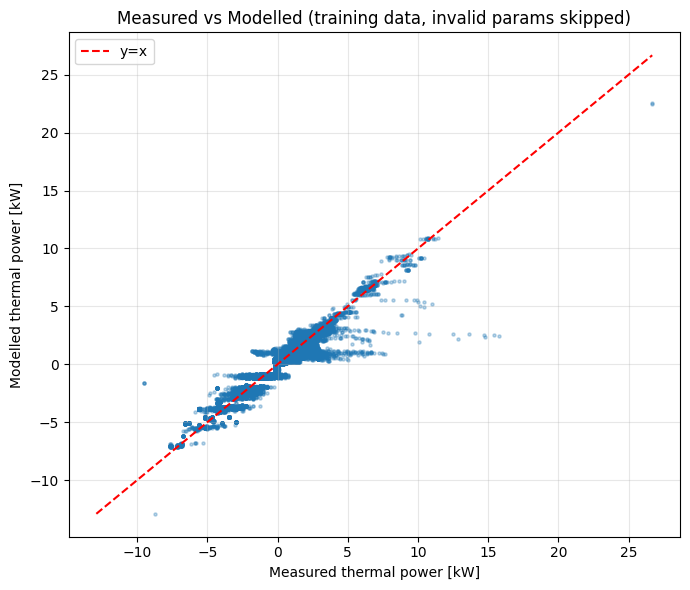

In [8]:
# === Build model prediction using param_df (NaNs = skip those contributions) ===

# param_df index = zone_ids, columns = flow_fan combinations
zone_ids = list(param_df_constrained.index)
combos   = param_df_constrained.columns  # e.g. ["Off_Off","Cooling_Medium",...]

# helper mapping fan numeric → labels
fan_state_map = {
    0.0: "Off",
    0.5: "Low",
    1.0: "Medium",
    1.5: "High",
}

def get_param(flow, fan, zone_id):
    """Return parameter if exists & not NaN, else return 0."""
    col = f"{flow}_{fan}"
    if col not in param_df_constrained.columns:
        return 0
    val = param_df_constrained.loc[zone_id, col]
    return 0 if pd.isna(val) else val


# ===== simulate model =====
P_model_list = []
P_meas_list  = []
t_list       = []

for t in cal_df_clean.index:

    flow = cal_df_clean.at[t, "flow_cluster"]
    if flow not in flow_states:
        continue  # skip Ostalo

    supply_T = cal_df_clean.at[t, "supply_temperature"]
    power    = 0.0

    for zone in zone_ids:
        Tz = zone_df_clean.at[t, zone]
        fan_val = fan_df_clean.at[t, zone]
        fan_lbl = fan_state_map.get(fan_val, None)

        if fan_lbl not in fan_states:
            continue
        if pd.isna(Tz) or pd.isna(supply_T):
            continue

        theta = get_param(flow, fan_lbl, zone)
        if theta == 0:
            continue  # NaN or non-existing parameter → ignore

        deltaT = supply_T - Tz
        power += theta * deltaT

    P_model_list.append(power)
    P_meas_list.append(cal_df_clean.at[t, "thermal_power_man"])
    t_list.append(t)

valid_df = pd.DataFrame({
    "P_measured": P_meas_list,
    "P_model": P_model_list,
}, index=pd.to_datetime(t_list)).sort_index()
dfv = valid_df.dropna()

err  = dfv.P_model - dfv.P_measured
MAE  = err.abs().mean()
RMSE = np.sqrt((err**2).mean())

# R2
ss_res = np.sum(err**2)
ss_tot = np.sum((dfv.P_measured - dfv.P_measured.mean())**2)
R2 = 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

print("\n=== TRAINING FIT STATISTICS (NaN params removed) ===")
print(f"MAE  : {MAE:.2f} kW")
print(f"RMSE : {RMSE:.2f} kW")
print(f"R²   : {R2:.3f}")

# SCATTER PLOT
plt.figure(figsize=(7,6))
plt.scatter(dfv.P_measured, dfv.P_model, s=5, alpha=0.3)

lims = [min(dfv.P_measured.min(), dfv.P_model.min()),
        max(dfv.P_measured.max(), dfv.P_model.max())]

plt.plot(lims, lims, 'r--', label="y=x")
plt.xlabel("Measured thermal power [kW]")
plt.ylabel("Modelled thermal power [kW]")
plt.title("Measured vs Modelled (training data, invalid params skipped)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



=== TRAINING FIT STATISTICS (NaN params removed) ===
MAE  : 0.19 kW
RMSE : 0.32 kW
R²   : 0.914


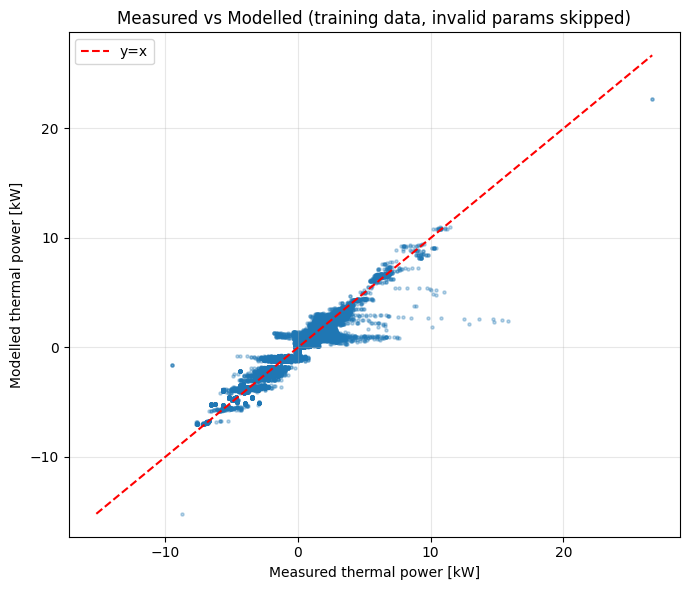

In [9]:
# === Build model prediction using param_df (NaNs = skip those contributions) ===

# param_df index = zone_ids, columns = flow_fan combinations
zone_ids = list(param_df_ols.index)
combos   = param_df_ols.columns  # e.g. ["Off_Off","Cooling_Medium",...]

# helper mapping fan numeric → labels
fan_state_map = {
    0.0: "Off",
    0.5: "Low",
    1.0: "Medium",
    1.5: "High",
}

def get_param(flow, fan, zone_id):
    """Return parameter if exists & not NaN, else return 0."""
    col = f"{flow}_{fan}"
    if col not in param_df_ols.columns:
        return 0
    val = param_df_ols.loc[zone_id, col]
    return 0 if pd.isna(val) else val


# ===== simulate model =====
P_model_list = []
P_meas_list  = []
t_list       = []

for t in cal_df_clean.index:

    flow = cal_df_clean.at[t, "flow_cluster"]
    if flow not in flow_states:
        continue  # skip Ostalo

    supply_T = cal_df_clean.at[t, "supply_temperature"]
    power    = 0.0

    for zone in zone_ids:
        Tz = zone_df_clean.at[t, zone]
        fan_val = fan_df_clean.at[t, zone]
        fan_lbl = fan_state_map.get(fan_val, None)

        if fan_lbl not in fan_states:
            continue
        if pd.isna(Tz) or pd.isna(supply_T):
            continue

        theta = get_param(flow, fan_lbl, zone)
        if theta == 0:
            continue  # NaN or non-existing parameter → ignore

        deltaT = supply_T - Tz
        power += theta * deltaT

    P_model_list.append(power)
    P_meas_list.append(cal_df_clean.at[t, "thermal_power_man"])
    t_list.append(t)

valid_df = pd.DataFrame({
    "P_measured": P_meas_list,
    "P_model": P_model_list,
}, index=pd.to_datetime(t_list)).sort_index()
dfv = valid_df.dropna()

err  = dfv.P_model - dfv.P_measured
MAE  = err.abs().mean()
RMSE = np.sqrt((err**2).mean())

# R2
ss_res = np.sum(err**2)
ss_tot = np.sum((dfv.P_measured - dfv.P_measured.mean())**2)
R2 = 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

print("\n=== TRAINING FIT STATISTICS (NaN params removed) ===")
print(f"MAE  : {MAE:.2f} kW")
print(f"RMSE : {RMSE:.2f} kW")
print(f"R²   : {R2:.3f}")

# SCATTER PLOT
plt.figure(figsize=(7,6))
plt.scatter(dfv.P_measured, dfv.P_model, s=5, alpha=0.3)

lims = [min(dfv.P_measured.min(), dfv.P_model.min()),
        max(dfv.P_measured.max(), dfv.P_model.max())]

plt.plot(lims, lims, 'r--', label="y=x")
plt.xlabel("Measured thermal power [kW]")
plt.ylabel("Modelled thermal power [kW]")
plt.title("Measured vs Modelled (training data, invalid params skipped)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
